# Colonization vs persistence: how much of the FPC change is range shift?

**Question.** the foliar èprojective cover `FPC = crown_footprint × (1 − exp(−0.5·LAI))` carries both signals of expansion in area and in-place leaf densification. When the foliar projection cover of a PFT increases, the vegetation either is moving into *new* cells
(colonization = range shift) or it is thickening where it *already is* (persistence =
in-place densification). This matters because `FPC = crown_footprint × (1 − exp(−0.5·LAI))` and carries both signals of expansion in area and in-place leaf densification. In our experiments, we want to record the area expansion information (mainly linked to increase in temperature), while leaving aside the leaf densification (mainly due to the CO2 fertilisation effect) - i.e. LAI, which will be prognostic in CLM runs.

**Definitions (per cell, per PFT).**
- colonization: FPC_hist < EPS  AND  FPC_fut >= EPS   (absent -> present)
- persistence:  FPC_hist >= EPS AND  FPC_fut >= EPS   (present both times)
- colonization *share* = (positive dFPC in colonizing cells) / (all positive dFPC)

**Two methodological choices this notebook makes explicit** (both bit us before):
1. **Grid.** Compute on the NATIVE 0.5deg grid, where "absent -> present" is a
   real range edge. On a coarse grid colonization is under-detected (coarse
   cells already hold a trace of every PFT). We show both to prove the point.
2. **EPS threshold.** The share depends on EPS; we sweep it so the number we
   report is a considered choice, not an accident. (An earlier "~85-95%"
   figure could not be reproduced here at EPS=0.02; the sweep shows why.)

**Data.** Uses the historical + future FPC. If you have the new monthly files,
use peak-month (annual-max) FPC for both periods (set USE_PEAK=True and provide
both). Otherwise it falls back to the annual per-PFT files.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
plt.rcParams.update({"font.family":"STIXGeneral","mathtext.fontset":"stix"})

DATA = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/LPJ-GUESS")
LPJ_NATURAL = ["BNE","BINE","BNS","TeNE","TeBE","IBS","TeBS","C3G",
               "HSE","HSS","LSE","LSS","GRT","EPDS","SPDS","CLM"]

# ---- choose the FPC source --------------------------------------------------
# Option A: annual per-PFT files (original)
FPC_HIST = DATA / "fpc1971to2000.txt"
FPC_FUT  = DATA / "GFDL-ESM4_SSP585_fpc2071to2100.txt"
# Option B: peak-month from monthly climatology (needs BOTH periods monthly)
USE_PEAK = False
#FPC_HIST_MONTHLY = DATA / "mfpc_pft_avg_1970_2000_monthly_mean.out"   # <-- need from Jing
FPC_FUT_MONTHLY  = DATA / "mfpc_pft_avg_2070_2100_monthly_mean.out"

EPS = 0.02          # presence threshold (swept in section 3)


## Loaders


In [2]:
def load_annual(path, names=LPJ_NATURAL):
    df = pd.read_csv(path, sep=r"\s+").set_index(["Lat","Lon"])[names]
    da = xr.DataArray(df.values, coords={"lonlat":df.index,"natpft":names},
                      dims=["lonlat","natpft"]).unstack("lonlat")
    return da.rename({"Lat":"lat","Lon":"lon"}).transpose("natpft","lat","lon")

def load_peak(path, names=LPJ_NATURAL):
    df = pd.read_csv(path, sep=r"\s+", low_memory=False)
    df = df[df["Lon"]!="Lon"].copy()
    df[["Lon","Lat","Month"]] = df[["Lon","Lat","Month"]].astype(float)
    df[names] = df[names].astype(float)
    da = (df.set_index(["Month","Lat","Lon"])[names].to_xarray().to_array("natpft"))
    da = da.transpose("natpft","Month","Lat","Lon").rename({"Lat":"lat","Lon":"lon"})
    return da.max("Month")     # annual maximum (peak month) per PFT per cell

if USE_PEAK:
    fpc_hist = load_peak(FPC_HIST_MONTHLY); fpc_fut = load_peak(FPC_FUT_MONTHLY)
    basis = "peak-month (annual max)"
else:
    fpc_hist = load_annual(FPC_HIST); fpc_fut = load_annual(FPC_FUT)
    basis = "annual per-PFT file"
xr.align(fpc_hist, fpc_fut, join="exact")
mask = np.isfinite(fpc_hist).all("natpft")
print("FPC basis:", basis, "| cells:", int(mask.sum()))


FPC basis: annual per-PFT file | cells: 16750


## 1 · Colonization share per PFT (native grid)
FPC-gain-weighted share of the positive change coming from colonizing cells.


In [3]:
def colonization_share(fh, ff, m, eps=EPS, area_weight=True):
    dF = (ff - fh).where(m)
    w  = np.cos(np.deg2rad(fh.lat)) if area_weight else xr.ones_like(fh.lat, dtype=float)
    pos = dF > 0
    colon = (fh < eps) & (ff >= eps)
    tot  = float((dF.where(pos) * w).sum())
    coln = float((dF.where(pos & colon) * w).sum())
    return (coln/tot*100 if tot > 0 else np.nan), tot

rows = []
for p in LPJ_NATURAL:
    pc, tot = colonization_share(fpc_hist.sel(natpft=p), fpc_fut.sel(natpft=p), mask)
    rows.append((p, pc, tot))
tab = pd.DataFrame(rows, columns=["PFT","colonization %","+dFPC gain"]).sort_values("+dFPC gain", ascending=False)
print(f"area-weighted, EPS={EPS}, basis={basis}:")
print(tab.to_string(index=False, float_format=lambda x: f"{x:.1f}"))


area-weighted, EPS=0.02, basis=annual per-PFT file:
 PFT  colonization %  +dFPC gain
 IBS            47.4       618.8
 BNS            17.0       553.4
BINE            41.0       450.1
 BNE            60.9       374.1
 C3G            85.4       294.7
 HSS            89.8       151.3
 GRT            54.2       100.5
TeBS            73.3        77.6
 LSS            76.1        55.3
 LSE            45.4        13.3
 HSE            41.0         8.2
SPDS            16.6         4.1
EPDS            44.7         3.5
TeNE             0.0         0.1
TeBE             0.0         0.0
 CLM             0.0         0.0


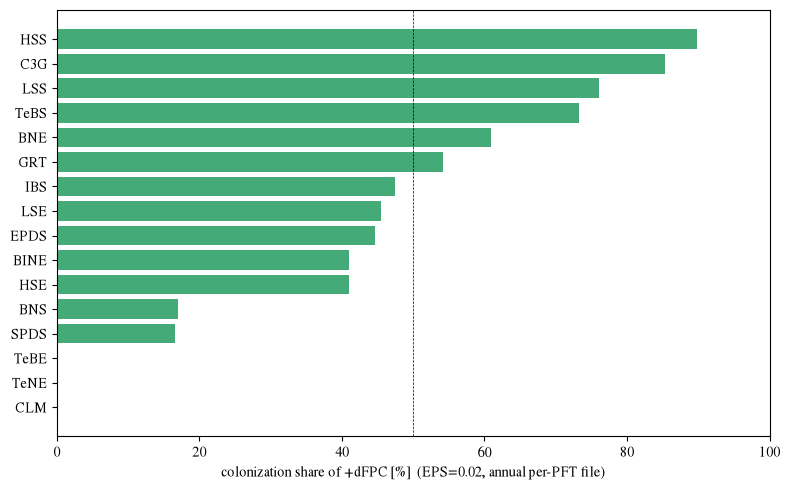

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
t = tab.sort_values("colonization %")
ax.barh(t["PFT"], t["colonization %"], color="#4a7")
ax.axvline(50, color="k", lw=0.5, ls="--"); ax.set_xlim(0,100)
ax.set_xlabel(f"colonization share of +dFPC [%]  (EPS={EPS}, {basis})")
plt.tight_layout()


## 2 · Grouped by CLM target (the numbers for the paper)
BoNET (BNE+BINE), BoNDT (BNS/larch), BoBDT (IBS).


In [5]:
groups = {"BoNET":["BNE","BINE"], "BoNDT (larch)":["BNS"], "BoBDT":["IBS"],
          "BoBDS shrubs":["HSE","HSS","LSE","LSS","EPDS","SPDS"], "aC3":["C3G","GRT"]}
print(f"{'group':16s} {'coloniz %':>10} {'+dFPC':>8}")
for nm, cols in groups.items():
    fh = fpc_hist.sel(natpft=cols).sum("natpft")
    ff = fpc_fut.sel(natpft=cols).sum("natpft")
    pc, tot = colonization_share(fh, ff, mask)
    print(f"{nm:16s} {pc:9.0f}% {tot:8.1f}")


group             coloniz %    +dFPC
BoNET                   55%    669.1
BoNDT (larch)           17%    553.4
BoBDT                   47%    618.8
BoBDS shrubs            19%    154.7
aC3                     33%    214.3


## 3 · EPS sensitivity — is the share a robust number or a threshold artifact?
Sweep the presence threshold; if the share swings wildly, the metric is
threshold-driven and must be reported WITH its EPS. (This likely explains an
earlier much-higher figure: a looser EPS counts more cells as "absent" hist.)


In [6]:
eps_grid = [0.01, 0.02, 0.05, 0.10, 0.20]
print(f"{'group':16s}" + "".join(f"{f'EPS={e}':>10}" for e in eps_grid))
for nm, cols in groups.items():
    fh = fpc_hist.sel(natpft=cols).sum("natpft")
    ff = fpc_fut.sel(natpft=cols).sum("natpft")
    line = f"{nm:16s}"
    for e in eps_grid:
        pc, _ = colonization_share(fh, ff, mask, eps=e)
        line += f"{pc:9.0f}%"
    print(line)


group             EPS=0.01  EPS=0.02  EPS=0.05   EPS=0.1   EPS=0.2
BoNET                  50%       55%       62%       65%       65%
BoNDT (larch)          14%       17%       24%       36%       51%
BoBDT                  40%       47%       56%       62%       66%
BoBDS shrubs            6%       19%       55%       67%       30%
aC3                    30%       33%       40%       44%       38%


## 4 · Native vs coarse grid (why the grid matters)
Requires the regridded fields `fpc_hist_clm`/`fpc_fut_clm` and `valid` from the
main surfdata notebook. Skips gracefully if not present.


In [7]:
try:
    print(f"{'group':16s} {'native %':>9} {'coarse %':>9}")
    for nm, cols in groups.items():
        fh_n = fpc_hist.sel(natpft=cols).sum("natpft")
        ff_n = fpc_fut.sel(natpft=cols).sum("natpft")
        fh_c = fpc_hist_clm.sel(natpft=cols).sum("natpft")
        ff_c = fpc_fut_clm.sel(natpft=cols).sum("natpft")
        pc_n,_ = colonization_share(fh_n, ff_n, mask)
        pc_c,_ = colonization_share(fh_c, ff_c, valid)
        print(f"{nm:16s} {pc_n:8.0f}% {pc_c:8.0f}%")
except NameError:
    print("run the main surfdata notebook first for fpc_hist_clm / fpc_fut_clm / valid")


group             native %  coarse %
run the main surfdata notebook first for fpc_hist_clm / fpc_fut_clm / valid


## 5 · Maps: colonization cells vs persist-densification
Green = newly colonized; orange = densifying where already present.


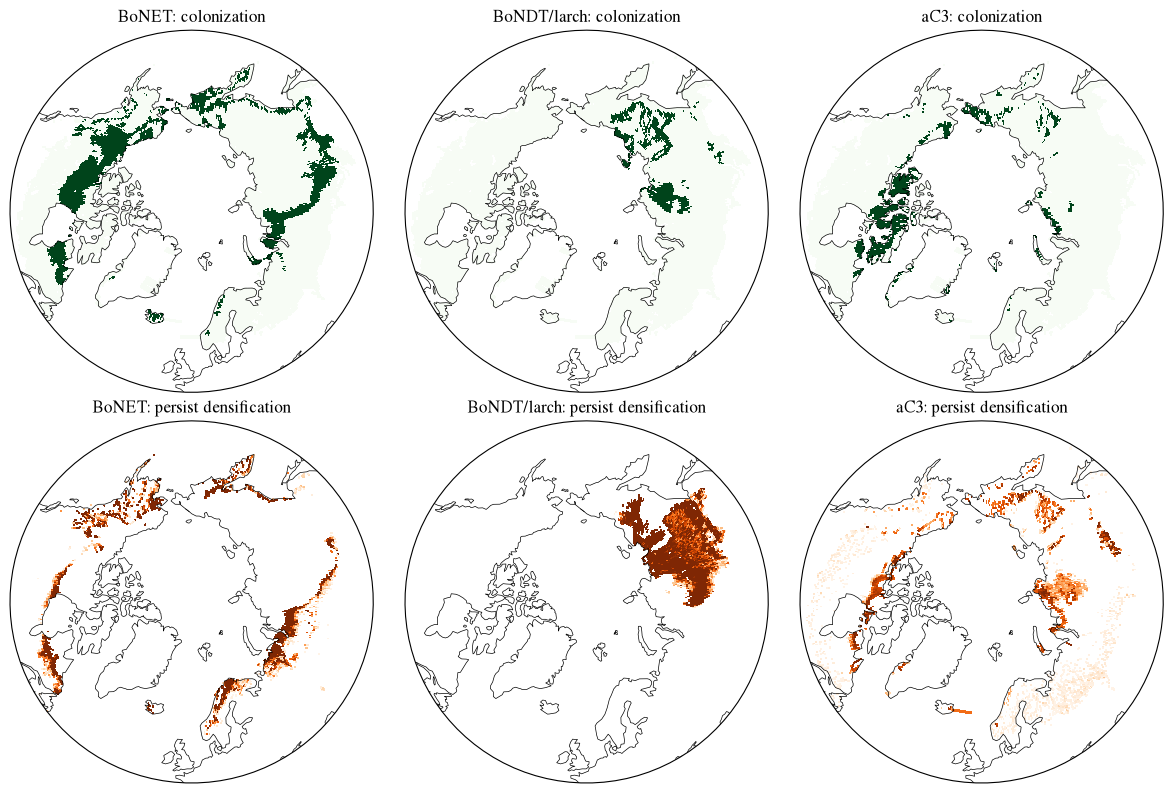

In [8]:
def _circle(ax):
    t = np.linspace(0,2*np.pi,100)
    ax.set_boundary(mpath.Path(np.vstack([np.sin(t),np.cos(t)]).T*0.5+[0.5,0.5]), transform=ax.transAxes)
def bmap(da, title, ax, **kw):
    ax.set_extent([-180,180,45,90], ccrs.PlateCarree()); _circle(ax)
    da.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), add_colorbar=False, **kw)
    ax.coastlines(linewidth=0.5); ax.set_title(title)

show = {"BoNET":["BNE","BINE"], "BoNDT/larch":["BNS"], "aC3":["C3G","GRT"]}
fig, axes = plt.subplots(2, len(show), figsize=(4*len(show), 8),
                         subplot_kw={"projection": ccrs.Orthographic(0,90)})
for k,(nm,cols) in enumerate(show.items()):
    fh = fpc_hist.sel(natpft=cols).sum("natpft"); ff = fpc_fut.sel(natpft=cols).sum("natpft")
    colon = ((fh < EPS)&(ff >= EPS)).where(mask)
    dens  = (ff - fh).where((fh >= EPS)&(ff >= EPS)&(ff > fh))
    bmap(colon.astype(float), f"{nm}: colonization", axes[0,k], cmap="Greens", vmin=0, vmax=1)
    bmap(dens, f"{nm}: persist densification", axes[1,k], cmap="Oranges", vmin=0, vmax=0.3)
plt.tight_layout()
